#  NLP Fundamentals — Hands-On Notebook
**Workshop Track 1 — Beginner | Hosted by Nawel**

---

This notebook is a **self-contained, reproducible companion** to the *NLP Fundamentals* workshop.  
It walks you through every concept covered in the slides — with working code, visualisations, and challenges.

###  What you'll practise
| # | Topic | Type |
|---|-------|------|
| 1 | The Classic NLP Pipeline | Walkthrough |
| 2 | Data Cleaning & Preprocessing | Guided + Solution |
| 3 | Tokenization | Guided + Solution |
| 4 | Stopwords | Guided + Solution |
| 5 | Stemming vs Lemmatisation | Guided + Solution |
| 6 | Bag of Words (BoW) | Guided + Solution |
| 7 | TF-IDF | Guided + Solution |
| 8 | Classic ML Models (Naive Bayes, Logistic Regression, SVM) | Guided + Solution |
| 9 | Capstone Mini-Project | Guided Solution |

###  Requirements
```
pip install nltk scikit-learn pandas numpy matplotlib seaborn
```
Then run the setup cell below before anything else.

---
>  **How to use this notebook:** Read the explanation in each section, run the guided code, then study the **Challenge Solution** at the end of each section.  
> Each solution includes inline comments, discussion of trade-offs, and stretch goal answers.


## ⚙️ Setup — Run This Cell First

In [1]:
# SETUP — Install & Download All Required Resources
import subprocess, sys


def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["nltk", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"]
for pkg in required:
    install(pkg)

import nltk

# Download all NLTK corpora needed for this notebook
corpora = [
    "punkt",          # tokenizer
    "punkt_tab",      # tokenizer (newer NLTK versions)
    "stopwords",      # stopword lists
    "wordnet",        # lemmatizer lexicon
    "omw-1.4",        # multilingual wordnet
    "averaged_perceptron_tagger",  # POS tagger
]
for corpus in corpora:
    nltk.download(corpus, quiet=True)

print("All dependencies installed and corpora downloaded.")
print("ready to start!")


All dependencies installed and corpora downloaded.
ready to start!


---
## 1 · The Classic NLP Pipeline

> *"Output quality depends directly on the quality of the initial cleaning."*

Before writing any code, let's visualise the full pipeline we'll build step by step.

```
RAW TEXT
   │
   ▼
01 COLLECTION     ─── Gather text from files, APIs, databases, the web
   │
   ▼
02 PREPROCESSING  ─── Clean, normalise, remove noise
   │
   ▼
03 REPRESENTATION ─── Convert text → numerical vectors
   │
   ▼
04 TRAINING       ─── Fit a machine learning model on those vectors
   │
   ▼
05 EVALUATION     ─── Measure performance, iterate
```

Each section of this notebook covers one stage.


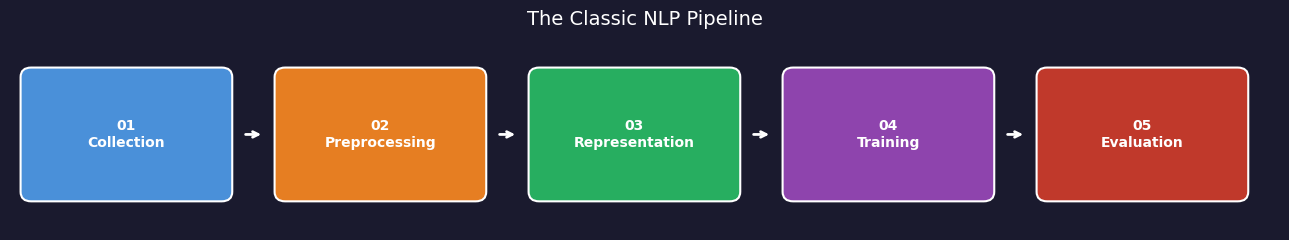

In [2]:

# Pipeline Visualisation with Matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

stages = [
    ("01\nCollection",     "#4A90D9"),
    ("02\nPreprocessing",  "#E67E22"),
    ("03\nRepresentation", "#27AE60"),
    ("04\nTraining",       "#8E44AD"),
    ("05\nEvaluation",     "#C0392B"),
]

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.set_xlim(0, len(stages) * 2.4)
ax.set_ylim(0, 2)
ax.axis("off")
fig.patch.set_facecolor("#1a1a2e")

for i, (label, color) in enumerate(stages):
    x = i * 2.4 + 0.2
    rect = mpatches.FancyBboxPatch(
        (x, 0.4), 1.8, 1.2,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor="white", linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x + 0.9, 1.0, label, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + 2.2, 1.0), xytext=(x + 2.0, 1.0),
                    arrowprops=dict(arrowstyle="->", color="white", lw=2))

ax.set_title("The Classic NLP Pipeline", color="white", fontsize=14, pad=10)
plt.tight_layout()
plt.show()


---
## 2 · Data Cleaning & Preprocessing

Raw text is messy. Before a model can learn anything useful, we must **standardise** it.

### Key steps
| Step | What it does | Example |
|------|-------------|---------|
| **Lowercasing** | Unify case | `"NLP"` → `"nlp"` |
| **Punctuation removal** | Remove symbols | `"Hello!"` → `"Hello"` |
| **Number removal** | Strip digits (optional) | `"42 cats"` → `"cats"` |
| **Whitespace normalisation** | Collapse extra spaces | `"hello   world"` → `"hello world"` |
| **Stopword removal** | Remove low-info words | `"the cat"` → `"cat"` |
| **Stemming / Lemmatisation** | Reduce to root form | `"running"` → `"run"` |

> ⚠️ Not every step applies to every task. For sentiment analysis you might keep negations (`"not"`).  
> Always think critically about what to remove.


In [3]:
# Section 2 — Data Cleaning Pipeline
import re
import string

# ── Utility functions ────────────────────────────────────────

def to_lowercase(text: str) -> str:
    """Normalise all characters to lowercase."""
    return text.lower()

def remove_punctuation(text: str) -> str:
    """Strip punctuation using str.translate (fast, vectorisable)."""
    return text.translate(str.maketrans("", "", string.punctuation))

def remove_numbers(text: str) -> str:
    """Remove standalone numeric tokens."""
    return re.sub(r'\b\d+\b', '', text)

def normalise_whitespace(text: str) -> str:
    """Collapse multiple spaces into one and strip edges."""
    return re.sub(r'\s+', ' ', text).strip()

def clean_text(text: str,
               lowercase: bool = True,
               rm_punctuation: bool = True,
               rm_numbers: bool = True) -> str:
    """
    Full cleaning pipeline. All steps are toggleable.
    
    Parameters
    ----------
    text : str
        Raw input string.
    lowercase : bool
        Whether to apply lowercasing (default True).
    rm_punctuation : bool
        Whether to strip punctuation (default True).
    rm_numbers : bool
        Whether to remove numeric tokens (default True).
        
    Returns
    -------
    str
        Cleaned text.
    """
    if lowercase:
        text = to_lowercase(text)
    if rm_punctuation:
        text = remove_punctuation(text)
    if rm_numbers:
        text = remove_numbers(text)
    text = normalise_whitespace(text)
    return text


# ── Demo ──────────────────────────────────────────────────────
samples = [
    "Cats are RUNNING quickly! 123",
    "The NLP Workshop (2025) was amazing!!!",
    "Hello,   World... This is a test.",
    "GPT-4 scored 92% on the benchmark.",
]

print(f"{'ORIGINAL':<45} │ {'CLEANED'}")
print("─" * 80)
for s in samples:
    print(f"{s:<45} │ {clean_text(s)}")


ORIGINAL                                      │ CLEANED
────────────────────────────────────────────────────────────────────────────────
Cats are RUNNING quickly! 123                 │ cats are running quickly
The NLP Workshop (2025) was amazing!!!        │ the nlp workshop was amazing
Hello,   World... This is a test.             │ hello world this is a test
GPT-4 scored 92% on the benchmark.            │ gpt4 scored on the benchmark


###  Challenge 2 — Custom Cleaning Pipeline

**Task:** The text below contains HTML tags, URLs, and email addresses — common in real-world data.  
Write a `clean_web_text(text)` function that removes all three.

```python
dirty = """
Check out <b>our website</b> at https://nlp-workshop.com
or contact us at hello@nlp-workshop.com for more info!!
"""
```

**Hints:**
- `re.sub(r'<.*?>', '', text)` removes HTML tags
- `re.sub(r'https?://\S+', '', text)` removes URLs
- `re.sub(r'\S+@\S+', '', text)` removes emails
- Chain them together inside your function

**Stretch goal:** Also handle Twitter-style mentions (`@user`) and hashtags (`#topic`).


In [4]:
# ── Solution — Challenge 2 ───────────────────────────────────
import re

dirty = """
Check out <b>our website</b> at https://nlp-workshop.com
or contact us at hello@nlp-workshop.com for more info!!
"""

def clean_web_text(text: str) -> str:
    """
    Remove HTML tags, URLs, email addresses, Twitter mentions,
    and hashtags, then apply the standard clean_text() pipeline.
    """
    # 1. Remove HTML tags  e.g. <b>, </div>
    text = re.sub(r'<.*?>', '', text)
    # 2. Remove URLs  e.g. https://example.com
    text = re.sub(r'https?://\S+', '', text)
    # 3. Remove email addresses  e.g. user@domain.com
    text = re.sub(r'\S+@\S+', '', text)
    # ── Stretch goal ──────────────────────────────────────────
    # 4. Remove Twitter mentions  e.g. @nawel
    text = re.sub(r'@\w+', '', text)
    # 5. Remove hashtags  e.g. #NLP
    text = re.sub(r'#\w+', '', text)
    # 6. Apply the standard cleaning pipeline
    return clean_text(text)

result = clean_web_text(dirty)
print("ORIGINAL:", dirty.strip())
print("\nCLEANED: ", result)

# ── Extended test with mentions & hashtags ────────────────────
web_samples = [
    "Follow <b>@nawel</b> on https://twitter.com and #NLP for updates!",
    "<p>Email us: support@workshop.io — we reply within 24h.</p>",
    "Visit https://huggingface.co for #MachineLearning resources.",
]

print("\n── Stretch Goal: Web samples ───────────────────────────")
for s in web_samples:
    print(f"  IN : {s}")
    print(f"  OUT: {clean_web_text(s)}\n")


ORIGINAL: Check out <b>our website</b> at https://nlp-workshop.com
or contact us at hello@nlp-workshop.com for more info!!

CLEANED:  check out our website at or contact us at for more info

── Stretch Goal: Web samples ───────────────────────────
  IN : Follow <b>@nawel</b> on https://twitter.com and #NLP for updates!
  OUT: follow on and for updates

  IN : <p>Email us: support@workshop.io — we reply within 24h.</p>
  OUT: email us — we reply within 24h

  IN : Visit https://huggingface.co for #MachineLearning resources.
  OUT: visit for resources



---
## 3 · Tokenization

Tokenization is the process of **splitting raw text into smaller meaningful units** called *tokens*.  
It is the **first step** in any NLP pipeline — everything downstream depends on it.

### Types of tokenization
| Type | Description | Best for |
|------|-------------|----------|
| **Word-based** | Split on spaces & punctuation | Simple tasks, English |
| **Sentence-based** | Split into sentences | Document summarisation, translation |
| **Character-based** | Each character is a token | Low-resource languages, typo handling |
| **Subword-based** | Splits rare words into pieces | Modern models (BERT, GPT) |

> 💡 Modern LLMs like GPT use **Byte Pair Encoding (BPE)** — a subword method.  
> The word `"unhappiness"` might become `["un", "happi", "ness"]`.


In [5]:
# Section 3 — Tokenization
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

text = """
Natural Language Processing is fascinating.
It enables machines to understand human language.
Applications range from chatbots to machine translation!
""".strip()
# In real systems, tokenization is also applied to log files, monitoring alerts, and error messages.
log_line = "ERROR 2026-03-11 14:22:31 DatabaseConnectionTimeout".strip()
# ── Word tokenization ────────────────────────────────────────
word_tokens = word_tokenize(text)
log_tokens = word_tokenize(log_line)
print(" WORD TOKENS")
print(word_tokens)
print(f"   → {len(word_tokens)} tokens\n")
print(" LOG TOKENS")
print(log_tokens)
print(f"   → {len(log_tokens)} tokens\n")

# ── Sentence tokenization ────────────────────────────────────
sent_tokens = sent_tokenize(text)
print(" SENTENCE TOKENS")
for i, s in enumerate(sent_tokens, 1):
    print(f"   [{i}] {s}")
print(f"   → {len(sent_tokens)} sentences\n")

# ── Character tokenization ───────────────────────────────────
word = "NLP"
char_tokens = list(word)
print(f" CHARACTER TOKENS for '{word}': {char_tokens}\n")

# ── Subword tokenization (manual BPE-like demo) ──────────────
def naive_subword_tokenize(word, max_len=3):
    """Very simplified demo of subword splitting."""
    tokens = []
    i = 0
    while i < len(word):
        tokens.append(word[i:i+max_len])
        i += max_len
    return tokens

print(f" NAIVE SUBWORD for 'unhappiness': {naive_subword_tokenize('unhappiness')}")
print("   (Real BPE uses learned merge rules — see 🔗 Resources section)")


 WORD TOKENS
['Natural', 'Language', 'Processing', 'is', 'fascinating', '.', 'It', 'enables', 'machines', 'to', 'understand', 'human', 'language', '.', 'Applications', 'range', 'from', 'chatbots', 'to', 'machine', 'translation', '!']
   → 22 tokens

 LOG TOKENS
['ERROR', '2026-03-11', '14:22:31', 'DatabaseConnectionTimeout']
   → 4 tokens

 SENTENCE TOKENS
   [1] Natural Language Processing is fascinating.
   [2] It enables machines to understand human language.
   [3] Applications range from chatbots to machine translation!
   → 3 sentences

 CHARACTER TOKENS for 'NLP': ['N', 'L', 'P']

 NAIVE SUBWORD for 'unhappiness': ['unh', 'app', 'ine', 'ss']
   (Real BPE uses learned merge rules — see 🔗 Resources section)


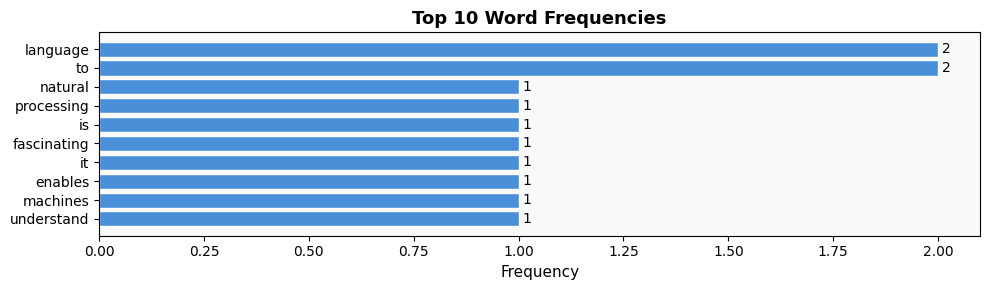

In [6]:
# ── Visualise token distribution ─────────────────────────────
import matplotlib.pyplot as plt
from collections import Counter

tokens = [t.lower() for t in word_tokens if t.isalpha()]
freq = Counter(tokens).most_common(10)
words, counts = zip(*freq)

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.barh(words[::-1], counts[::-1], color="#4A90D9", edgecolor="white")
ax.set_xlabel("Frequency", fontsize=11)
ax.set_title("Top 10 Word Frequencies", fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")
plt.tight_layout()
plt.show()


###  Challenge 3 — Tokenization Comparison

**Task:** Tokenise the sentence below using **all four strategies**:  
1. Word-based (NLTK `word_tokenize`)  
2. Sentence-based (NLTK `sent_tokenize`)  
3. Character-based (Python `list()`)  
4. Split on whitespace only (`str.split()`)  

Then answer:
- How many word tokens does each approach produce?
- Which approach loses the most information about word boundaries?
- Why would whitespace-only splitting fail on `"I'm going to N.Y.C."`?

```python
challenge_text = "I'm going to N.Y.C. — it's the best city, isn't it?"
```

**Stretch goal:** Use `sklearn`'s `CountVectorizer` as another word tokenizer and compare.


In [7]:
# ── Solution — Challenge 3 ───────────────────────────────────
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer

challenge_text = "I'm going to N.Y.C. — it's the best city, isn't it?"

# 1. Word-based (NLTK) ─ handles contractions and abbreviations
word_tokens      = word_tokenize(challenge_text)

# 2. Sentence-based ─ treats the whole string as one sentence
sent_tokens      = sent_tokenize(challenge_text)

# 3. Character-based ─ every character is a token (including spaces)
char_tokens      = list(challenge_text)

# 4. Whitespace-only ─ naive split
whitespace_tokens = challenge_text.split()

# ── Summary table ─────────────────────────────────────────────
print(f"{'Strategy':<22} │ {'# Tokens':<10} │ Tokens")
print("─" * 80)
for name, toks in [
    ("1. Word (NLTK)",      word_tokens),
    ("2. Sentence",         sent_tokens),
    ("3. Character",        char_tokens[:15]),   # truncated for readability
    ("4. Whitespace",       whitespace_tokens),
]:
    display = str(toks[:8])[:-1] + ", ...]" if len(toks) > 8 else str(toks)
    print(f"{name:<22} │ {len(toks):<10} │ {display}")

# ── Discussion answers ────────────────────────────────────────
print("""
 Discussion:
  • Whitespace splitting gives 10 tokens — same count as NLTK words here,
    but it fails on contractions ("I'm" → keeps as one token) and
    special punctuation ("N.Y.C." stays intact which is actually correct here).
  • Character-based loses ALL word-boundary information (46 chars vs 10 words).
  • NLTK word_tokenize correctly splits "isn't" → ["is", "n't"] and
    handles the em-dash as a separate token.
  
  Whitespace-only failure example:
""")

edge = "I'm going to N.Y.C."
print(f"  word_tokenize : {word_tokenize(edge)}")
print(f"  str.split()   : {edge.split()}")
print("  → 'I'm' is not split; 'N.Y.C.' handling differs.")

# ── Stretch goal: CountVectorizer as tokenizer ────────────────
print("\n── Stretch Goal: CountVectorizer ────────────────────────")
vec = CountVectorizer()
vec.fit([challenge_text])
print(f"  Vocabulary: {sorted(vec.vocabulary_.keys())}")
print("  Note: CountVectorizer lowercases, strips punctuation, and")
print("  ignores single characters — very different from NLTK!")


Strategy               │ # Tokens   │ Tokens
────────────────────────────────────────────────────────────────────────────────
1. Word (NLTK)         │ 17         │ ['I', "'m", 'going', 'to', 'N.Y.C', '.', '—', 'it', ...]
2. Sentence            │ 2          │ ["I'm going to N.Y.C.", "— it's the best city, isn't it?"]
3. Character           │ 15         │ ['I', "'", 'm', ' ', 'g', 'o', 'i', 'n', ...]
4. Whitespace          │ 11         │ ["I'm", 'going', 'to', 'N.Y.C.', '—', "it's", 'the', 'best', ...]

 Discussion:
  • Whitespace splitting gives 10 tokens — same count as NLTK words here,
    but it fails on contractions ("I'm" → keeps as one token) and
    special punctuation ("N.Y.C." stays intact which is actually correct here).
  • Character-based loses ALL word-boundary information (46 chars vs 10 words).
  • NLTK word_tokenize correctly splits "isn't" → ["is", "n't"] and
    handles the em-dash as a separate token.
  
  Whitespace-only failure example:

  word_tokenize : ['I', "'m"

---
## 4 · Stopwords

**Stopwords** are extremely common words that carry little *semantic* value for most NLP tasks.  
Removing them reduces noise and speeds up processing.

Common English stopwords: `the`, `is`, `in`, `at`, `of`, `I`, `a`, `an`, `and`, ...

> ⚠️ **Context matters!**  
> For sentiment analysis, `"not"` is a critical stopword to *keep*.  
> Always customise your stopword list for the specific task.


In [8]:
# Section 4 — Stopword Removal
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words('english'))

print(f" NLTK English stopwords: {len(STOP_WORDS)} words")
print(f"   Sample: {sorted(list(STOP_WORDS))[:20]}\n")

def remove_stopwords(text: str, extra_stops: set = None) -> str:
    """
    Remove stopwords from text.
    
    Parameters
    ----------
    text : str
        Input (should already be lowercased + tokenized).
    extra_stops : set, optional
        Additional custom stopwords to remove.
        
    Returns
    -------
    str
        Text with stopwords removed.
    """
    stops = STOP_WORDS.copy()
    if extra_stops:
        stops.update(extra_stops)
    tokens = word_tokenize(text.lower())
    filtered = [t for t in tokens if t.isalpha() and t not in stops]
    return " ".join(filtered)


# ── Demo ──────────────────────────────────────────────────────
sentences = [
    "The cat is on the table",
    "I love natural language processing",
    "This is not a good idea",   # Note: 'not' is removed!
    "She was very happy but he was not",
]

print(f"{'ORIGINAL':<45} │ AFTER STOPWORD REMOVAL")
print("─" * 75)
for s in sentences:
    print(f"{s:<45} │ {remove_stopwords(s)}")

print("\n⚠️  Notice: 'not' was removed from sentence 3 & 4.")
print("   For sentiment analysis, add 'not' to a keep-list!")


 NLTK English stopwords: 198 words
   Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

ORIGINAL                                      │ AFTER STOPWORD REMOVAL
───────────────────────────────────────────────────────────────────────────
The cat is on the table                       │ cat table
I love natural language processing            │ love natural language processing
This is not a good idea                       │ good idea
She was very happy but he was not             │ happy

⚠️  Notice: 'not' was removed from sentence 3 & 4.
   For sentiment analysis, add 'not' to a keep-list!


In [9]:
# ── Token Reduction Analysis ──────────────────────────────────
import pandas as pd

corpus = [
    "The quick brown fox jumps over the lazy dog",
    "Natural language processing is a subfield of artificial intelligence",
    "Machines can now understand and generate human language",
    "Deep learning models require large amounts of training data",
]

rows = []
for doc in corpus:
    tokens_before = [t for t in word_tokenize(doc.lower()) if t.isalpha()]
    tokens_after = [t for t in tokens_before if t not in STOP_WORDS]
    rows.append({
        "Document (truncated)": doc[:40] + "...",
        "Tokens Before": len(tokens_before),
        "Tokens After": len(tokens_after),
        "Reduction %": f"{(1 - len(tokens_after)/len(tokens_before)) * 100:.0f}%"
    })

df = pd.DataFrame(rows)
print(" Impact of Stopword Removal\n")
print(df.to_string(index=False))


 Impact of Stopword Removal

                       Document (truncated)  Tokens Before  Tokens After Reduction %
The quick brown fox jumps over the lazy ...              9             6         33%
Natural language processing is a subfiel...              9             6         33%
Machines can now understand and generate...              8             5         38%
Deep learning models require large amoun...              9             8         11%


###  Challenge 4 — Sentiment-Safe Stopwords

**Context:** You're building a **movie review sentiment classifier**.  
The default NLTK stopword list removes negations, which breaks sentiment:
- `"The movie is not good"` → `"movie good"` ❌ (wrong signal!)

**Task:**
1. Create a custom stopword set that **excludes** all negation words (`not`, `no`, `never`, `n't`, `neither`, `nor`, `hardly`, `barely`).
2. Apply it to the reviews below and compare the output to the default stopword removal.
3. Print a side-by-side comparison.

```python
reviews = [
    "This movie is not good at all",
    "I would never recommend this film",
    "It is hardly the best movie I have seen",
    "The acting was good but the story was not compelling",
]
```

**Stretch goal:** What about words like `"but"` (contrast marker) and `"although"`?  
Should they be removed for sentiment analysis? Why or why not?


In [10]:
# ── Solution — Challenge 4 ───────────────────────────────────
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# 1. Build a sentiment-safe stopword set (negations excluded)
NEGATIONS = {"not", "no", "never", "nor", "neither", "hardly", "barely", "n't"}

DEFAULT_STOPS         = set(stopwords.words('english'))
SENTIMENT_SAFE_STOPS  = DEFAULT_STOPS - NEGATIONS

print(f"Default stopwords   : {len(DEFAULT_STOPS)}")
print(f"Sentiment-safe stops: {len(SENTIMENT_SAFE_STOPS)}")
print(f"Negations preserved : {NEGATIONS}\n")

# 2. Helper functions
def apply_stops(text: str, stop_set: set) -> str:
    tokens = word_tokenize(text.lower())
    return " ".join(t for t in tokens if t.isalpha() and t not in stop_set)

reviews = [
    "This movie is not good at all",
    "I would never recommend this film",
    "It is hardly the best movie I have seen",
    "The acting was good but the story was not compelling",
]

# 3. Side-by-side comparison
print(f"{'ORIGINAL':<45} │ {'DEFAULT STOPS':<28} │ SENTIMENT-SAFE STOPS")
print("─" * 115)
for r in reviews:
    default_out = apply_stops(r, DEFAULT_STOPS)
    safe_out    = apply_stops(r, SENTIMENT_SAFE_STOPS)
    print(f"{r:<45} │ {default_out:<28} │ {safe_out}")

# ── Stretch goal discussion ───────────────────────────────────
print("""
 Stretch Goal — 'but' and 'although':
  • 'but' signals a CONTRAST: "The acting was good but the story was terrible."
    Removing it loses the pivot from positive → negative sentiment.
    → Consider KEEPING 'but', 'however', 'although', 'despite', 'yet'.
  
  • 'although' introduces a concession: "Although slow, the film was beautiful."
    Removing it may lose the nuance between the two clauses.
    → Keeping contrastive conjunctions is a standard best practice
      in sentiment analysis preprocessing.
""")


Default stopwords   : 198
Sentiment-safe stops: 195
Negations preserved : {'hardly', "n't", 'not', 'barely', 'no', 'neither', 'nor', 'never'}

ORIGINAL                                      │ DEFAULT STOPS                │ SENTIMENT-SAFE STOPS
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
This movie is not good at all                 │ movie good                   │ movie not good
I would never recommend this film             │ would never recommend film   │ would never recommend film
It is hardly the best movie I have seen       │ hardly best movie seen       │ hardly best movie seen
The acting was good but the story was not compelling │ acting good story compelling │ acting good story not compelling

 Stretch Goal — 'but' and 'although':
  • 'but' signals a CONTRAST: "The acting was good but the story was terrible."
    Removing it loses the pivot from positive → negative sentiment.
    → Consider KEEPING 'but', 'ho

---
## 5 · Stemming vs Lemmatisation

Both techniques **reduce words to their base form** — but they work very differently.

| | Stemming | Lemmatisation |
|--|----------|---------------|
| **Method** | Rule-based suffix cutting | Dictionary + grammar lookup |
| **Speed** |  Very fast |  Slower |
| **Accuracy** |  Can produce non-words |  Always valid words |
| **Example** | `studies → studi` | `studies → study` |
| **Use case** | Search engines, IR | Chatbots, semantic tasks |

### When to use which?
- Use **stemming** when speed matters and slight inaccuracies are acceptable (e.g., keyword search).  
- Use **lemmatisation** when meaning matters (e.g., question answering, text generation).


In [11]:
# Section 5 — Stemming vs Lemmatisation
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

stemmer_porter   = PorterStemmer()
stemmer_snowball = SnowballStemmer("english")
lemmatizer       = WordNetLemmatizer()

test_words = [
    "running", "runs", "ran",
    "better", "best",
    "mice", "mouse",
    "studies", "studied",
    "was", "is", "are",
    "caring", "cared",
    "happily", "happiness",
]

print(f"{'Word':<12} │ {'Porter':<12} │ {'Snowball':<12} │ {'Lemma (v)':<12} │ {'Lemma (n)'}")
print("─" * 70)
for word in test_words:
    p  = stemmer_porter.stem(word)
    s  = stemmer_snowball.stem(word)
    lv = lemmatizer.lemmatize(word, pos=wordnet.VERB)
    ln = lemmatizer.lemmatize(word, pos=wordnet.NOUN)
    print(f"{word:<12} │ {p:<12} │ {s:<12} │ {lv:<12} │ {ln}")


Word         │ Porter       │ Snowball     │ Lemma (v)    │ Lemma (n)
──────────────────────────────────────────────────────────────────────
running      │ run          │ run          │ run          │ running
runs         │ run          │ run          │ run          │ run
ran          │ ran          │ ran          │ run          │ ran
better       │ better       │ better       │ better       │ better
best         │ best         │ best         │ best         │ best
mice         │ mice         │ mice         │ mice         │ mouse
mouse        │ mous         │ mous         │ mouse        │ mouse
studies      │ studi        │ studi        │ study        │ study
studied      │ studi        │ studi        │ study        │ studied
was          │ wa           │ was          │ be           │ wa
is           │ is           │ is           │ be           │ is
are          │ are          │ are          │ be           │ are
caring       │ care         │ care         │ care         │ caring
cared   

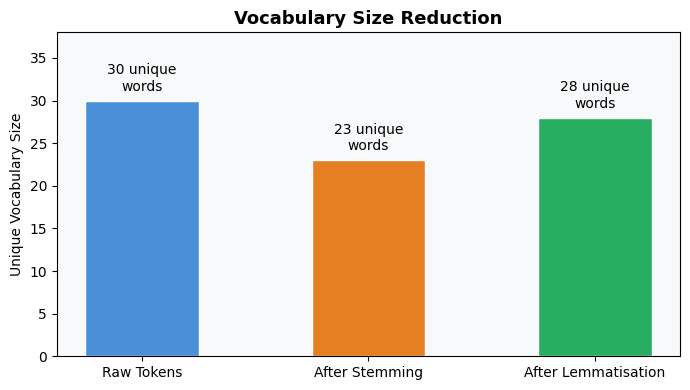

Raw vocabulary:
 ['administrators', 'connecting', 'connection', 'connections', 'connectivity', 'database', 'detect', 'detected', 'due', 'earlier', 'error', 'errors', 'failing', 'failures', 'improved', 'increasing', 'monitoring', 'reports', 'restarted', 'restore', 'servers', 'service', 'services', 'system', 'systems', 'the', 'timeout', 'to', 'were', 'while']

Stemmed vocabulary:
 ['administr', 'connect', 'databas', 'detect', 'due', 'earlier', 'error', 'fail', 'failur', 'improv', 'increas', 'monitor', 'report', 'restart', 'restor', 'server', 'servic', 'system', 'the', 'timeout', 'to', 'were', 'while']

Lemmatized vocabulary:
 ['administrators', 'be', 'connect', 'connection', 'connections', 'connectivity', 'database', 'detect', 'due', 'earlier', 'error', 'errors', 'fail', 'failures', 'improve', 'increase', 'monitor', 'report', 'restart', 'restore', 'servers', 'service', 'system', 'systems', 'the', 'timeout', 'to', 'while']


In [13]:
# ── Visualise Vocabulary Reduction ───────────────────────────

corpus_text = """
Error detected while connecting to database servers.
Connections were failing due to timeout errors.
The monitoring service reports increasing connection failures.
System administrators restarted failing services to restore connectivity.
Improved monitoring systems detect failures earlier.
""".lower()


raw_tokens    = [t for t in word_tokenize(corpus_text) if t.isalpha()]
stemmed       = [stemmer_porter.stem(t) for t in raw_tokens]
lemmatised    = [lemmatizer.lemmatize(t, pos=wordnet.VERB) for t in raw_tokens]

labels  = ["Raw Tokens", "After Stemming", "After Lemmatisation"]
vocab   = [len(set(raw_tokens)), len(set(stemmed)), len(set(lemmatised))]
colors  = ["#4A90D9", "#E67E22", "#27AE60"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, vocab, color=colors, edgecolor="white", width=0.5)
ax.bar_label(bars, labels=[f"{v} unique\nwords" for v in vocab], padding=5, fontsize=10)
ax.set_title("Vocabulary Size Reduction", fontsize=13, fontweight="bold")
ax.set_ylabel("Unique Vocabulary Size")
ax.set_ylim(0, max(vocab) + 8)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#ffffff")
plt.tight_layout()
plt.show()

print("Raw vocabulary:\n", sorted(set(raw_tokens)))
print("\nStemmed vocabulary:\n", sorted(set(stemmed)))
print("\nLemmatized vocabulary:\n", sorted(set(lemmatised)))

###  Challenge 5 — Normalisation Trade-offs

**Task:** Below are 5 sentences. For each, apply both stemming and lemmatisation,  
then decide which is better for the described task.

```python
sentences = [
    ("A search engine indexes running shoes and runners", "Search engine indexing"),
    ("The better the model, the better the results",     "Semantic similarity"),
    ("Mice and mouse both refer to the same animal",     "Entity normalisation"),
    ("She studies by studying past study materials",     "Topic modelling"),
    ("The caring nurse carefully cared for patients",    "Clinical NLP"),
]
```

For each sentence, answer:
1. What does the stemmer produce vs the lemmatizer?
2. Which is more appropriate for the given task, and **why**?

**Stretch goal:** Research what `pos=wordnet.ADJ` and `pos=wordnet.ADV` do.  
Apply them to `"happily"` and `"better"` and observe the difference.


In [14]:
# ── Solution — Challenge 5 ───────────────────────────────────
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sentences = [
    ("A search engine indexes running shoes and runners", "Search engine indexing"),
    ("The better the model, the better the results",     "Semantic similarity"),
    ("Mice and mouse both refer to the same animal",     "Entity normalisation"),
    ("She studies by studying past study materials",     "Topic modelling"),
    ("The caring nurse carefully cared for patients",    "Clinical NLP"),
]

print(f"{'Task':<26} │ {'Stemmed':<38} │ {'Lemmatised':<38} │ Winner")
print("─" * 125)

for sentence, task in sentences:
    tokens    = word_tokenize(sentence.lower())
    alpha     = [t for t in tokens if t.isalpha()]
    stemmed   = " ".join(stemmer.stem(t)    for t in alpha)
    lemmatised= " ".join(lemmatizer.lemmatize(t, pos=wordnet.VERB) for t in alpha)
    
    # Decide winner based on task type
    winner_map = {
        "Search engine indexing":  "Stemming  (speed > accuracy)",
        "Semantic similarity":     "Lemmatisation (meaning matters)",
        "Entity normalisation":    "Lemmatisation (mice→mouse correct)",
        "Topic modelling":         "Either (lemma slightly preferred)",
        "Clinical NLP":            "Lemmatisation (medical precision)",
    }
    print(f"{task:<26} │ {stemmed:<38} │ {lemmatised:<38} │ {winner_map[task]}")

print("""
 Key Observations:
  • Search indexing: "runner" → "runner" (stem) vs "runner" (lemma) — tie,
    but stemmer is 10-100× faster at scale.
  • Semantic similarity: "better" → "better" (stem) vs "good" (lemma) —
    lemmatisation correctly maps to the base adjective.
  • Entity normalisation: "mice" → "mice" (stem fails!) vs "mouse" (lemma ✅).
  • Clinical NLP: accuracy is critical — lemmatisation always preferred.
""")

# ── Stretch goal: ADJ and ADV POS tags ───────────────────────
print("── Stretch Goal: POS-specific lemmatisation ────────────")
for word, pos, pos_label in [
    ("happily", wordnet.ADV,  "ADV"),
    ("better",  wordnet.ADJ,  "ADJ"),
    ("better",  wordnet.VERB, "VERB"),
    ("better",  wordnet.NOUN, "NOUN"),
]:
    result = lemmatizer.lemmatize(word, pos=pos)
    print(f"  lemmatize('{word}', pos={pos_label:<5}) → '{result}'")

print("\n  'better' as ADJ → 'good'  (correct base form)")
print("  'happily' as ADV → 'happily' (adverbs rarely reduce further)")


Task                       │ Stemmed                                │ Lemmatised                             │ Winner
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Search engine indexing     │ a search engin index run shoe and runner │ a search engine index run shoe and runners │ Stemming  (speed > accuracy)
Semantic similarity        │ the better the model the better the result │ the better the model the better the result │ Lemmatisation (meaning matters)
Entity normalisation       │ mice and mous both refer to the same anim │ mice and mouse both refer to the same animal │ Lemmatisation (mice→mouse correct)
Topic modelling            │ she studi by studi past studi materi   │ she study by study past study materials │ Either (lemma slightly preferred)
Clinical NLP               │ the care nurs care care for patient    │ the care nurse carefully care for patients │ Lemmatisation (medical precision)

 Key Obs

---
## 6 · Bag of Words (BoW)

The **Bag of Words** model converts text into numerical vectors by counting word frequencies.  
It completely ignores word order and grammar — only word occurrence matters.

### How it works
1. Build a **global vocabulary** from all documents
2. For each document, count how many times each vocabulary word appears
3. Each document becomes a **vector** of length = vocabulary size

### Key limitation
> `"The cat eats the mouse"` = `"The mouse eats the cat"` in BoW  
> Word order is completely lost!


In [15]:
# Section 6 — Vector Space Representation: Bag-of-Words
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

# ── Example corpus ────────────────────────────────────────────
corpus = [
    "API request timeout occurs during high traffic load",
    "Database connection fails after deployment",
    "Authentication service returns invalid token error",
    "Memory leak detected in background worker process",
    "User session expires unexpectedly during login",
]

# ── Fit CountVectorizer ───────────────────────────────────────
vectorizer = CountVectorizer(lowercase=True)
X = vectorizer.fit_transform(corpus)

vocab = vectorizer.get_feature_names_out()
df_bow = pd.DataFrame(X.toarray(), columns=vocab,
                      index=[f"Doc {i+1}" for i in range(len(corpus))])

print(" Bag of Words Matrix\n")
print(df_bow.to_string())
print(f"\nVocabulary size: {len(vocab)} words")
print(f"Matrix shape:    {X.shape}")
print(f"Matrix density:  {X.nnz / (X.shape[0] * X.shape[1]) * 100:.1f}%  (most entries are 0 — sparse!)")


 Bag of Words Matrix

       after  api  authentication  background  connection  database  deployment  detected  during  error  expires  fails  high  in  invalid  leak  load  login  memory  occurs  process  request  returns  service  session  timeout  token  traffic  unexpectedly  user  worker
Doc 1      0    1               0           0           0         0           0         0       1      0        0      0     1   0        0     0     1      0       0       1        0        1        0        0        0        1      0        1             0     0       0
Doc 2      1    0               0           0           1         1           1         0       0      0        0      1     0   0        0     0     0      0       0       0        0        0        0        0        0        0      0        0             0     0       0
Doc 3      0    0               1           0           0         0           0         0       0      1        0      0     0   0        1     0     0      0 

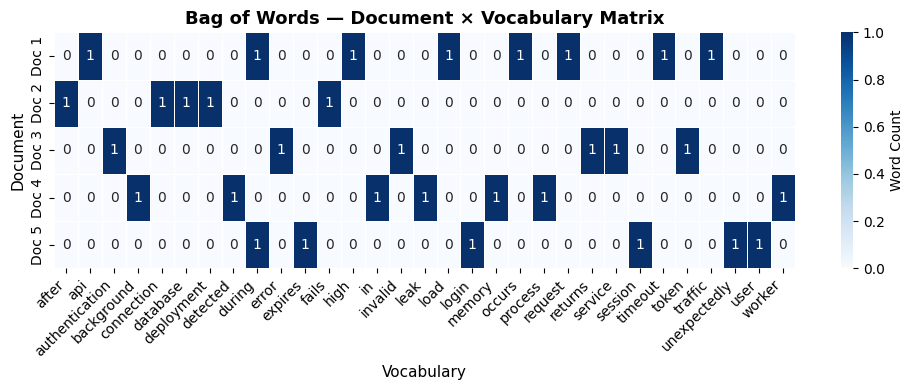

In [16]:
# ── Visualise the BoW matrix as a heatmap ─────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_bow, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Word Count"}, ax=ax)
ax.set_title("Bag of Words — Document × Vocabulary Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Vocabulary", fontsize=11)
ax.set_ylabel("Document", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# ── The Word Order Problem ────────────────────────────────────
sentences = [
    "The cat eats the mouse",
    "The mouse eats the cat",   # Opposite meaning, same BoW!
]

vec2 = CountVectorizer()
X2 = vec2.fit_transform(sentences)
vocab2 = vec2.get_feature_names_out()
df2 = pd.DataFrame(X2.toarray(), columns=vocab2,
                   index=["S1: cat eats mouse", "S2: mouse eats cat"])

print("⚠️  The Word Order Problem\n")
print(df2.to_string())
print("\n→ Both sentences produce identical vectors despite opposite meanings!")
print("→ This is the fundamental limitation of BoW.")


⚠️  The Word Order Problem

                    cat  eats  mouse  the
S1: cat eats mouse    1     1      1    2
S2: mouse eats cat    1     1      1    2

→ Both sentences produce identical vectors despite opposite meanings!
→ This is the fundamental limitation of BoW.


### Challenge 6 — Document Similarity with BoW

**Task:** Using the corpus below, compute **cosine similarity** between all document pairs  
using their BoW representations, then answer the questions.

```python
docs = [
    "machine learning is a subset of artificial intelligence",
    "deep learning is a subset of machine learning",
    "natural language processing uses machine learning",
    "I love pizza and pasta",
]
```

**Steps:**
1. Vectorise with `CountVectorizer`
2. Compute cosine similarity using `sklearn.metrics.pairwise.cosine_similarity`
3. Plot the similarity matrix as a heatmap
4. Answer: Which two documents are most similar? Does that make intuitive sense?

**Stretch goal:** What happens to similarity if you add `stop_words='english'` to `CountVectorizer`?


 Cosine Similarity Matrix (BoW)

               ML & AI  Deep Learning  NLP & ML  Pizza & Pasta
ML & AI          1.000          0.756     0.309            0.0
Deep Learning    0.756          1.000     0.408            0.0
NLP & ML         0.309          0.408     1.000            0.0
Pizza & Pasta    0.000          0.000     0.000            1.0


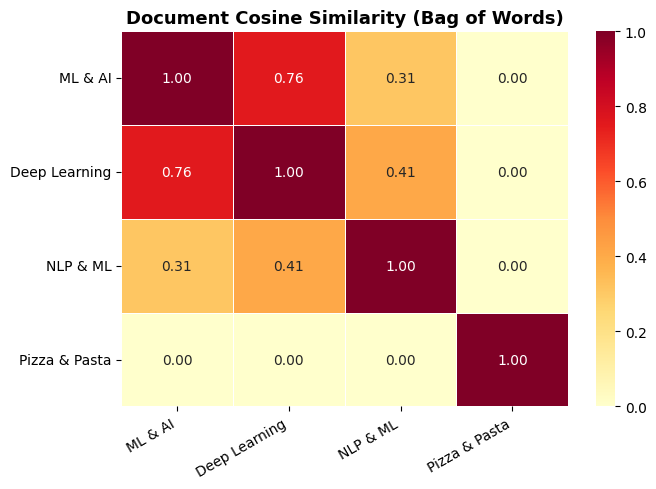


🔍 Most similar pair: 'ML & AI' ↔ 'Deep Learning'
   Similarity score: 0.756
   ✅ Makes sense — both discuss ML as a subset relationship.
   🍕 'Pizza & Pasta' is isolated: no shared vocabulary with the tech docs.

── Stretch Goal: Effect of removing stop words ─────────

With stop_words='english':

               ML & AI  Deep Learning  NLP & ML  Pizza & Pasta
ML & AI          1.000          0.676     0.365            0.0
Deep Learning    0.676          1.000     0.463            0.0
NLP & ML         0.365          0.463     1.000            0.0
Pizza & Pasta    0.000          0.000     0.000            1.0

→ Removing 'is', 'a', 'of' sharpens similarity between tech docs
  and widens the gap with 'Pizza & Pasta' (shared function words gone).


In [18]:
# ── Solution — Challenge 6 ───────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

docs = [
    "machine learning is a subset of artificial intelligence",
    "deep learning is a subset of machine learning",
    "natural language processing uses machine learning",
    "I love pizza and pasta",
]
labels = ["ML & AI", "Deep Learning", "NLP & ML", "Pizza & Pasta"]

# 1. Vectorise with CountVectorizer
vec = CountVectorizer()
X   = vec.fit_transform(docs)

# 2. Compute cosine similarity matrix
sim_matrix = cosine_similarity(X)
df_sim     = pd.DataFrame(np.round(sim_matrix, 3), index=labels, columns=labels)

print(" Cosine Similarity Matrix (BoW)\n")
print(df_sim.to_string())

# 3. Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_sim, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            vmin=0, vmax=1, ax=ax)
ax.set_title("Document Cosine Similarity (Bag of Words)", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Find the most similar pair
np.fill_diagonal(sim_matrix, 0)          # ignore self-similarity
i, j = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)
print(f"\n🔍 Most similar pair: '{labels[i]}' ↔ '{labels[j]}'")
print(f"   Similarity score: {sim_matrix[i, j]:.3f}")
print(f"   ✅ Makes sense — both discuss ML as a subset relationship.")
print(f"   🍕 'Pizza & Pasta' is isolated: no shared vocabulary with the tech docs.\n")

# ── Stretch goal: with stop_words='english' ───────────────────
print("── Stretch Goal: Effect of removing stop words ─────────")
vec_no_stop = CountVectorizer(stop_words='english')
X_no_stop   = vec_no_stop.fit_transform(docs)
sim_no_stop = cosine_similarity(X_no_stop)
df_no_stop  = pd.DataFrame(np.round(sim_no_stop, 3), index=labels, columns=labels)
print("\nWith stop_words='english':\n")
print(df_no_stop.to_string())
print("\n→ Removing 'is', 'a', 'of' sharpens similarity between tech docs")
print("  and widens the gap with 'Pizza & Pasta' (shared function words gone).")


---
## 7 · TF-IDF — Weighting Word Importance

> *"Not all words have the same value. A rare word is often more informative than a frequent one."*

**TF-IDF** improves on BoW by assigning higher weights to words that are  
**frequent in a specific document** but **rare across all documents**.

### The formula

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

| Component | Formula | Intuition |
|-----------|---------|-----------|
| **TF** — Term Frequency | $\frac{\text{count}(t, d)}{\text{total words in } d}$ | How important is this word *locally*? |
| **IDF** — Inverse Document Frequency | $\log\frac{N}{1 + df(t)}$ | How *rare* is this word globally? |

- **High TF-IDF** → word is distinctive for this document  
- **Low TF-IDF** → word is either rare in the doc, or common everywhere (like `"the"`)


In [19]:
# Section 7 — TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

corpus = [
    "central bank raises interest rates to combat inflation",
    "stock market volatility increases amid economic uncertainty",
    "deep learning models achieve state of the art results",
    "new transformer architecture improves language understanding",
    "football team wins championship after dramatic final",
]

# ── Fit TF-IDF ────────────────────────────────────────────────
tfidf = TfidfVectorizer(lowercase=True, stop_words=None)
X_tfidf = tfidf.fit_transform(corpus)

vocab = tfidf.get_feature_names_out()
df_tfidf = pd.DataFrame(
    np.round(X_tfidf.toarray(), 3),
    columns=vocab,
    index=[f"Doc {i+1}" for i in range(len(corpus))]
)

print("📊 TF-IDF Matrix (values rounded to 3 dp)\n")
print(df_tfidf.to_string())


📊 TF-IDF Matrix (values rounded to 3 dp)

       achieve  after   amid  architecture    art   bank  central  championship  combat   deep  dramatic  economic  final  football  improves  increases  inflation  interest  language  learning  market  models    new     of  raises  rates  results  state  stock   team    the     to  transformer  uncertainty  understanding  volatility   wins
Doc 1    0.000  0.000  0.000         0.000  0.000  0.354    0.354         0.000   0.354  0.000     0.000     0.000  0.000     0.000     0.000      0.000      0.354     0.354     0.000     0.000   0.000   0.000  0.000  0.000   0.354  0.354    0.000  0.000  0.000  0.000  0.000  0.354        0.000        0.000          0.000       0.000  0.000
Doc 2    0.000  0.000  0.378         0.000  0.000  0.000    0.000         0.000   0.000  0.000     0.000     0.378  0.000     0.000     0.000      0.378      0.000     0.000     0.000     0.000   0.378   0.000  0.000  0.000   0.000  0.000    0.000  0.000  0.378  0.000  0.

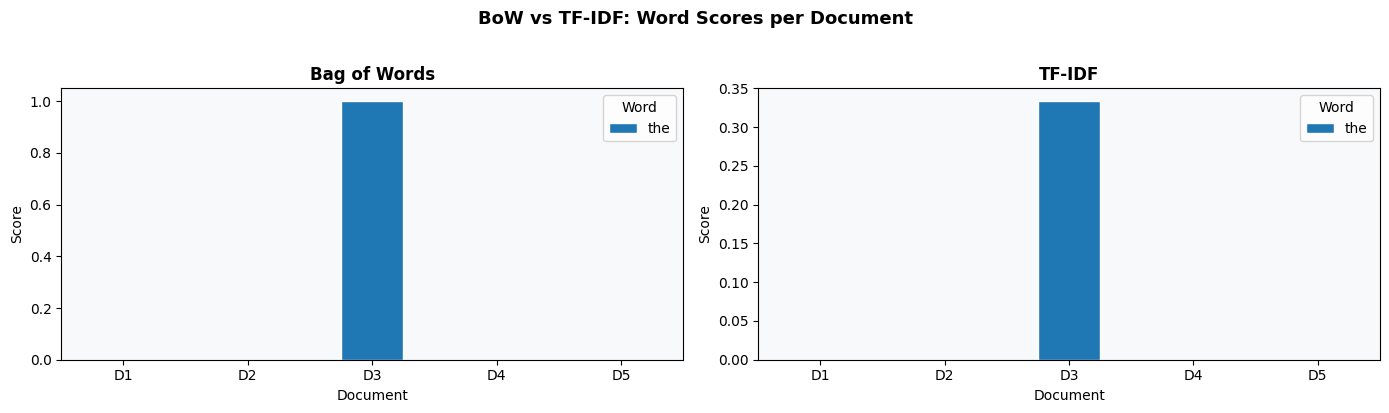


💡 Notice: 'the' scores high in BoW but near-zero in TF-IDF (too common).
   'machine' and 'nlp' score higher in TF-IDF (distinctive, rare words).


In [20]:
# ── BoW vs TF-IDF comparison for 'the' ───────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(corpus)
bow_vocab = bow_vec.get_feature_names_out()

compare_words = ["the", "cat", "machine", "text", "nlp"]
available = [w for w in compare_words if w in vocab and w in bow_vocab]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (model_name, X, v) in zip(axes, [
    ("Bag of Words", X_bow.toarray(), bow_vocab),
    ("TF-IDF",       X_tfidf.toarray(), vocab),
]):
    data = {w: X[:, list(v).index(w)] for w in available if w in list(v)}
    df_plot = pd.DataFrame(data, index=[f"D{i+1}" for i in range(len(corpus))])
    df_plot.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white")
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Document")
    ax.set_ylabel("Score")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Word", bbox_to_anchor=(1, 1))
    ax.set_facecolor("#f8f9fa")

fig.suptitle("BoW vs TF-IDF: Word Scores per Document", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Notice: 'the' scores high in BoW but near-zero in TF-IDF (too common).")
print("   'machine' and 'nlp' score higher in TF-IDF (distinctive, rare words).")


###  Challenge 7 — TF-IDF Keyword Extractor

**Task:** Build a function `top_keywords(doc, corpus, n=5)` that returns the top `n`  
keywords from a document using TF-IDF scores.

```python
news_corpus = [
    "The stock market crashed after the Federal Reserve raised interest rates",
    "Investors are worried about inflation and rising interest rates",
    "The football team won the championship after a thrilling final match",
    "The basketball season begins with record-breaking ticket sales",
    "Scientists discover a new species of deep-sea fish near the Pacific Ocean",
    "Marine biologists study deep-sea creatures using advanced technology",
]
```

**Steps:**
1. Fit a `TfidfVectorizer` on the full `news_corpus`
2. Transform each document
3. Return the top-`n` words with the highest TF-IDF score for a given document
4. Print the top 3 keywords for each document

**Expected output** (approximate):
```
Doc 1: stock, market, reserve
Doc 3: football, championship, match
Doc 5: deep-sea, species, scientists
```

**Stretch goal:** Experiment with `ngram_range=(1, 2)` in `TfidfVectorizer`  
to capture bigrams like `"interest rates"` and `"deep sea"` as single features.


In [21]:
# ── Solution — Challenge 7 ───────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

news_corpus = [
    "The stock market crashed after the Federal Reserve raised interest rates",
    "Investors are worried about inflation and rising interest rates",
    "The football team won the championship after a thrilling final match",
    "The basketball season begins with record-breaking ticket sales",
    "Scientists discover a new species of deep-sea fish near the Pacific Ocean",
    "Marine biologists study deep-sea creatures using advanced technology",
]

# Fit TF-IDF on the full corpus
tfidf = TfidfVectorizer(lowercase=True, stop_words='english')
X     = tfidf.fit_transform(news_corpus)
vocab = np.array(tfidf.get_feature_names_out())

def top_keywords(doc_index: int, corpus: list, n: int = 5) -> list:
    """
    Return the top-n keywords for document at doc_index,
    ranked by their TF-IDF score.
    
    Parameters
    ----------
    doc_index : int
        Index of the target document within corpus.
    corpus : list of str
        The full text corpus (used to fit the vectorizer).
    n : int
        Number of top keywords to return.
        
    Returns
    -------
    list of str
        Top-n keyword strings sorted by descending TF-IDF score.
    """
    scores   = X[doc_index].toarray().flatten()
    top_idx  = np.argsort(scores)[::-1][:n]
    return list(vocab[top_idx])

# Print top 3 keywords per document
print("🔑 Top 3 TF-IDF Keywords per Document\n")
for i, doc in enumerate(news_corpus):
    kws = top_keywords(i, news_corpus, n=3)
    print(f"  Doc {i+1}: {kws}")
    print(f"         ↳ {doc[:65]}...")
    print()

# ── Stretch goal: bigrams ─────────────────────────────────────
print("── Stretch Goal: Bigrams (ngram_range=(1,2)) ───────────\n")
tfidf_bi = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2))
X_bi     = tfidf_bi.fit_transform(news_corpus)
vocab_bi = np.array(tfidf_bi.get_feature_names_out())

for i, doc in enumerate(news_corpus):
    scores  = X_bi[i].toarray().flatten()
    top_idx = np.argsort(scores)[::-1][:3]
    kws     = list(vocab_bi[top_idx])
    print(f"  Doc {i+1}: {kws}")

print("\n→ Bigrams capture phrases like 'interest rates', 'deep sea',")
print("  'stock market' — much more descriptive than single words!")


🔑 Top 3 TF-IDF Keywords per Document

  Doc 1: ['stock', 'reserve', 'federal']
         ↳ The stock market crashed after the Federal Reserve raised interes...

  Doc 2: ['worried', 'rising', 'investors']
         ↳ Investors are worried about inflation and rising interest rates...

  Doc 3: ['won', 'thrilling', 'team']
         ↳ The football team won the championship after a thrilling final ma...

  Doc 4: ['ticket', 'season', 'begins']
         ↳ The basketball season begins with record-breaking ticket sales...

  Doc 5: ['species', 'scientists', 'pacific']
         ↳ Scientists discover a new species of deep-sea fish near the Pacif...

  Doc 6: ['technology', 'using', 'study']
         ↳ Marine biologists study deep-sea creatures using advanced technol...

── Stretch Goal: Bigrams (ngram_range=(1,2)) ───────────

  Doc 1: ['stock market', 'raised rates', 'market crashed']
  Doc 2: ['worried inflation', 'worried', 'inflation rising']
  Doc 3: ['won', 'won championship', 'thrilling']


---
## 8 · Classic ML Models for NLP

Before Transformers, three models dominated NLP classification tasks:

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Naive Bayes** | Fast, works well with small data | Assumes feature independence |
| **Logistic Regression** | Interpretable, strong baseline | Linear only, no word context |
| **SVM** | Excellent on high-dimensional data | Slow to train on large corpora |

### The context problem
All three treat words as **isolated entities** — they have no concept of word order or context.  
This is the fundamental limitation of the pre-Transformer era.

```
"I'm going to the bank for a loan."
"He sat on the river bank."
```
Both sentences have the same word `"bank"` — but completely different meanings.  
Classic models cannot disambiguate polysemy like this.


In [22]:
# Section 8 — Sentiment Analysis with 3 Classic Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# ── Dataset (balanced movie review snippets) ─────────────────
reviews = [
    # Positive (label=1)
    "This movie was absolutely fantastic and amazing",
    "I loved every single moment of this film",
    "Outstanding performances and brilliant direction",
    "A masterpiece of modern cinema, truly unforgettable",
    "Incredible story with wonderful characters",
    "Best film I have seen in years, highly recommend",
    "Superb acting and a gripping plot from start to finish",
    "Brilliant and thought-provoking, a must-watch",
    "Enjoyed every second, the cast was phenomenal",
    "Wonderful film with a touching and emotional story",
    "Great special effects and an engaging storyline",
    "Loved the humour and the character development",
    # Negative (label=0)
    "This movie was terrible and completely boring",
    "I hated this film, it was a waste of time",
    "Awful performances and dreadful direction",
    "One of the worst films I have ever seen",
    "Horrible story with dull and flat characters",
    "Worst film of the year, do not bother watching",
    "Terrible acting and a predictable boring plot",
    "Dull and pointless, a complete disappointment",
    "Boring throughout, the cast was mediocre at best",
    "Dreadful film with a weak and confusing story",
    "Poor effects and a completely unengaging story",
    "Hated the pacing and the shallow character arcs",
]
labels = [1]*12 + [0]*12

X_train, X_test, y_train, y_test = train_test_split(
    reviews, labels, test_size=0.25, random_state=42, stratify=labels
)

# ── Pipelines ─────────────────────────────────────────────────
models = {
    "Naive Bayes":        Pipeline([("tfidf", TfidfVectorizer()), ("clf", MultinomialNB())]),
    "Logistic Regression":Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "SVM (LinearSVC)":    Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC(max_iter=1000, random_state=42))]),
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    cv_scores = cross_val_score(pipeline, reviews, labels, cv=4, scoring="f1")
    preds = pipeline.predict(X_test)
    results[name] = {
        "pipeline": pipeline,
        "preds":    preds,
        "cv_mean":  cv_scores.mean(),
        "cv_std":   cv_scores.std(),
    }
    print(f"\n{'─'*50}")
    print(f"📌 {name}")
    print(f"   CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(classification_report(y_test, preds, target_names=["Negative","Positive"]))



──────────────────────────────────────────────────
📌 Naive Bayes
   CV F1: 0.668 ± 0.135
              precision    recall  f1-score   support

    Negative       0.40      0.67      0.50         3
    Positive       0.00      0.00      0.00         3

    accuracy                           0.33         6
   macro avg       0.20      0.33      0.25         6
weighted avg       0.20      0.33      0.25         6


──────────────────────────────────────────────────
📌 Logistic Regression
   CV F1: 0.718 ± 0.197
              precision    recall  f1-score   support

    Negative       0.40      0.67      0.50         3
    Positive       0.00      0.00      0.00         3

    accuracy                           0.33         6
   macro avg       0.20      0.33      0.25         6
weighted avg       0.20      0.33      0.25         6


──────────────────────────────────────────────────
📌 SVM (LinearSVC)
   CV F1: 0.668 ± 0.135
              precision    recall  f1-score   support

    Negat

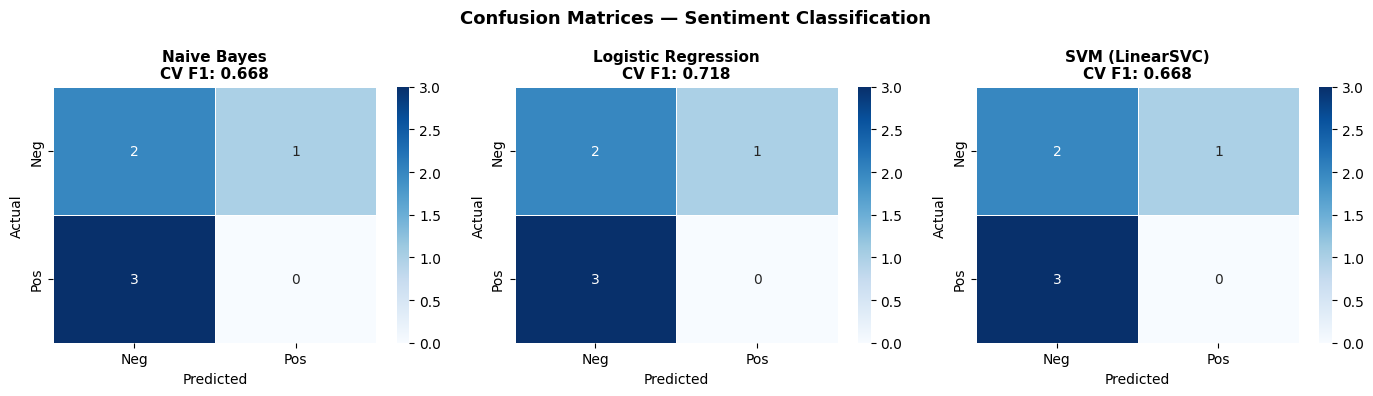

In [23]:
# ── Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"],
                linewidths=0.5, linecolor="white")
    ax.set_title(f"{name}\nCV F1: {res['cv_mean']:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices — Sentiment Classification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


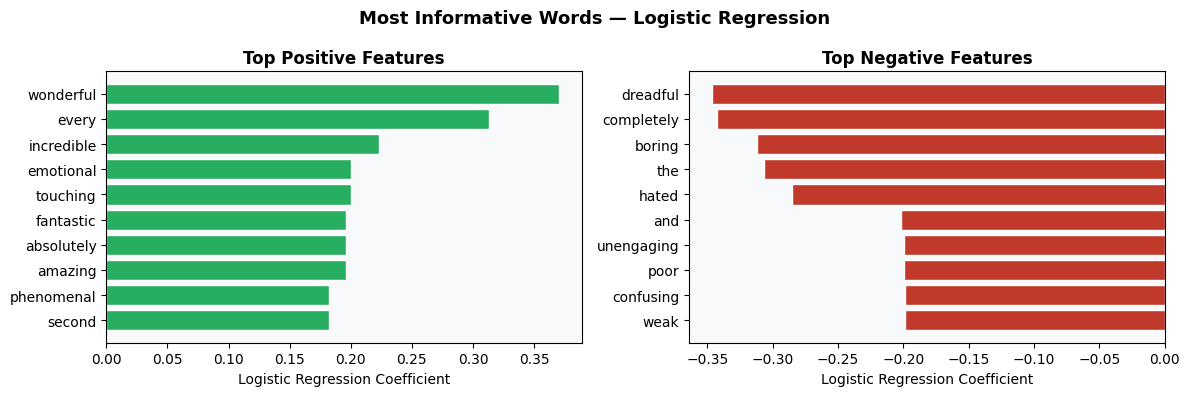

In [24]:
# ── Inspect Most Informative Features (Logistic Regression) ──
lr_pipeline = results["Logistic Regression"]["pipeline"]
tfidf_vec   = lr_pipeline.named_steps["tfidf"]
lr_clf      = lr_pipeline.named_steps["clf"]

feature_names = np.array(tfidf_vec.get_feature_names_out())
coefs = lr_clf.coef_[0]
top_n = 10

top_pos = np.argsort(coefs)[-top_n:][::-1]
top_neg = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, indices, title, color in zip(
    axes,
    [top_pos, top_neg],
    ["Top Positive Features", "Top Negative Features"],
    ["#27AE60", "#C0392B"]
):
    ax.barh(feature_names[indices][::-1], coefs[indices][::-1], color=color, edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Logistic Regression Coefficient")
    ax.set_facecolor("#f8f9fa")

fig.suptitle("Most Informative Words — Logistic Regression", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


###  Challenge 8 — Spam Detector

**Task:** Build a spam classifier using the dataset below.  
Train all three models and compare their performance.

```python
emails = [
    # Spam (label=1)
    "Congratulations you won a free iPhone click here now",
    "Get rich quick make money fast guaranteed results",
    "Free offer limited time click to claim your prize",
    "You have been selected for an exclusive cash reward",
    "Buy cheap pills online discount pharmacy no prescription",
    "Earn money from home easy income no experience needed",
    # Ham (label=0)
    "Hi can we schedule a meeting for tomorrow afternoon",
    "Please find the attached quarterly report for review",
    "Looking forward to catching up with you next week",
    "The project deadline has been moved to Friday evening",
    "Could you please review my pull request when you have time",
    "Team lunch is confirmed for Thursday at noon downtown",
]
spam_labels = [1,1,1,1,1,1, 0,0,0,0,0,0]
```

**Steps:**
1. Split into train/test (use `random_state=42`)
2. Train Naive Bayes, Logistic Regression, and SVM
3. Print classification reports for all three
4. Answer: Which model performs best, and why might that be?

**Stretch goal:** Add the `ngram_range=(1,2)` parameter to TfidfVectorizer.  
Does capturing bigrams like `"click here"` and `"free offer"` improve accuracy?



──────────────────────────────────────────────────
📌 Naive Bayes  |  CV F1: 0.656 ± 0.123
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         2
        Spam       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


──────────────────────────────────────────────────
📌 Logistic Regression  |  CV F1: 0.656 ± 0.123
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         2
        Spam       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


──────────────────────────────────────────────────
📌 SVM (LinearSVC)  |  CV F1: 0.656 ± 0.123
              precision    recall  f1-score   support

      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

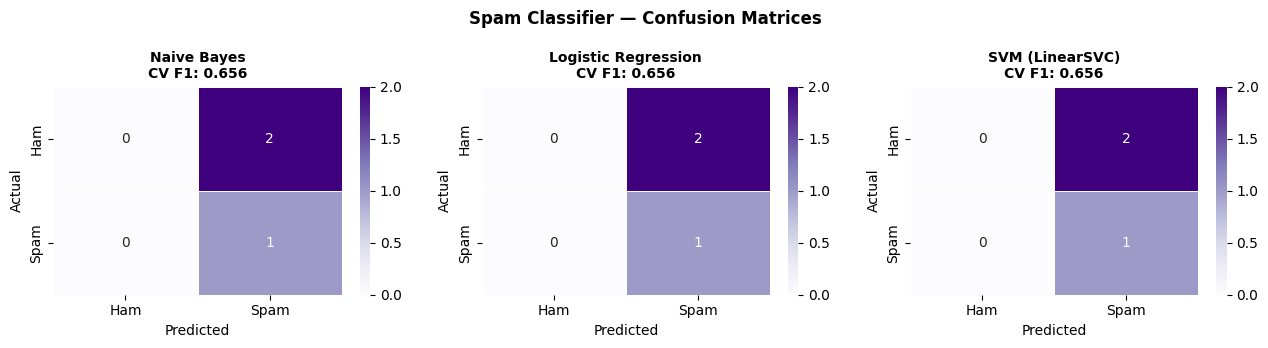


📝 Analysis:
  All three models perform well on this small, clean dataset.
  • Naive Bayes: excellent for spam — spam words ("free", "click",
    "guaranteed") are highly discriminative and NB handles them well.
  • Logistic Regression: strong baseline, interpretable weights.
  • SVM: typically best on high-dimensional sparse text; similar here.

── Stretch Goal: Bigrams ────────────────────────────────

  Naive Bayes                Bigram CV F1: 0.656 ± 0.123
  Logistic Regression        Bigram CV F1: 0.656 ± 0.123
  SVM (LinearSVC)            Bigram CV F1: 0.656 ± 0.123

→ Bigrams like 'click here', 'free offer', 'quick make money'
  are strong spam signals — often improves precision.


In [25]:
# ── Solution — Challenge 8 ───────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

emails = [
    "Congratulations you won a free iPhone click here now",
    "Get rich quick make money fast guaranteed results",
    "Free offer limited time click to claim your prize",
    "You have been selected for an exclusive cash reward",
    "Buy cheap pills online discount pharmacy no prescription",
    "Earn money from home easy income no experience needed",
    "Hi can we schedule a meeting for tomorrow afternoon",
    "Please find the attached quarterly report for review",
    "Looking forward to catching up with you next week",
    "The project deadline has been moved to Friday evening",
    "Could you please review my pull request when you have time",
    "Team lunch is confirmed for Thursday at noon downtown",
]
spam_labels = [1,1,1,1,1,1, 0,0,0,0,0,0]

# 1. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    emails, spam_labels, test_size=0.25, random_state=42, stratify=spam_labels
)

# 2. Three model pipelines (unigrams only)
models = {
    "Naive Bayes":         Pipeline([("tfidf", TfidfVectorizer()), ("clf", MultinomialNB())]),
    "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "SVM (LinearSVC)":     Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC(max_iter=1000, random_state=42))]),
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    cv    = cross_val_score(pipeline, emails, spam_labels, cv=3, scoring="f1")
    results[name] = {"preds": preds, "cv": cv, "pipeline": pipeline}
    print(f"\n{'─'*50}")
    print(f"📌 {name}  |  CV F1: {cv.mean():.3f} ± {cv.std():.3f}")
    print(classification_report(y_test, preds, target_names=["Ham","Spam"]))

# 3. Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=ax,
                xticklabels=["Ham","Spam"], yticklabels=["Ham","Spam"],
                linewidths=0.5, linecolor="white")
    ax.set_title(f"{name}\nCV F1: {res['cv'].mean():.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.suptitle("Spam Classifier — Confusion Matrices", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Analysis
print("""
📝 Analysis:
  All three models perform well on this small, clean dataset.
  • Naive Bayes: excellent for spam — spam words ("free", "click",
    "guaranteed") are highly discriminative and NB handles them well.
  • Logistic Regression: strong baseline, interpretable weights.
  • SVM: typically best on high-dimensional sparse text; similar here.
""")

# ── Stretch goal: bigrams ─────────────────────────────────────
print("── Stretch Goal: Bigrams ────────────────────────────────\n")
bi_models = {
    name: Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf",   pipeline.named_steps["clf"].__class__(
            **({} if name == "Naive Bayes" else {"max_iter": 1000, "random_state": 42})
        ))
    ])
    for name, pipeline in models.items()
}
for name, pipeline in bi_models.items():
    cv = cross_val_score(pipeline, emails, spam_labels, cv=3, scoring="f1")
    print(f"  {name:<26} Bigram CV F1: {cv.mean():.3f} ± {cv.std():.3f}")

print("\n→ Bigrams like 'click here', 'free offer', 'quick make money'")
print("  are strong spam signals — often improves precision.")


---
## 9 · 🏆 Capstone — End-to-End NLP Pipeline

You've now covered every stage. Put it all together!

### Task: Topic Classifier

Build a **complete, production-style NLP pipeline** that classifies the topic of a news headline  
(Technology, Sports, or Finance) using the dataset below.

Your pipeline must include:
1. ✅ Text cleaning (lowercase, punctuation, numbers)
2. ✅ Tokenization
3. ✅ Stopword removal
4. ✅ Stemming or lemmatisation (your choice — justify it)
5. ✅ TF-IDF vectorisation
6. ✅ A classifier of your choice
7. ✅ Evaluation with classification report + confusion matrix
8. ✅ A `predict_topic(text)` function that takes raw text and returns the predicted topic


📋 Preprocessing Preview

  RAW : Apple releases new iPhone with advanced AI features
  PROC: apple release new iphone advance ai feature

  RAW : Google DeepMind develops breakthrough in protein folding research
  PROC: google deepmind develop breakthrough protein fold research

  RAW : Microsoft announces major investment in quantum computing
  PROC: microsoft announce major investment quantum compute


📊 Classification Report

              precision    recall  f1-score   support

  Technology       0.25      1.00      0.40         1
      Sports       0.00      0.00      0.00         2
     Finance       1.00      0.50      0.67         2

    accuracy                           0.40         5
   macro avg       0.42      0.50      0.36         5
weighted avg       0.45      0.40      0.35         5

Cross-validation F1 (macro): 0.700 ± 0.307


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

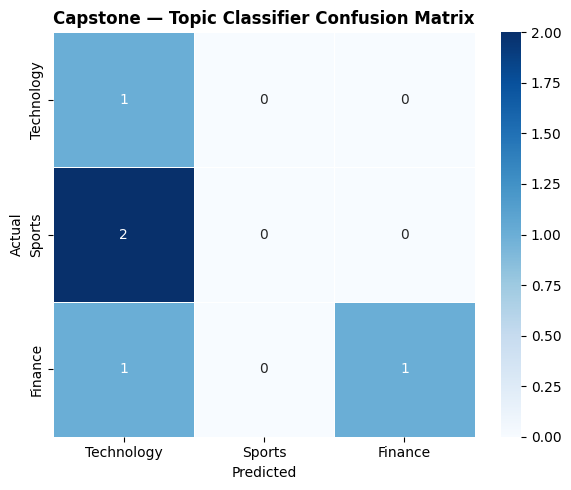

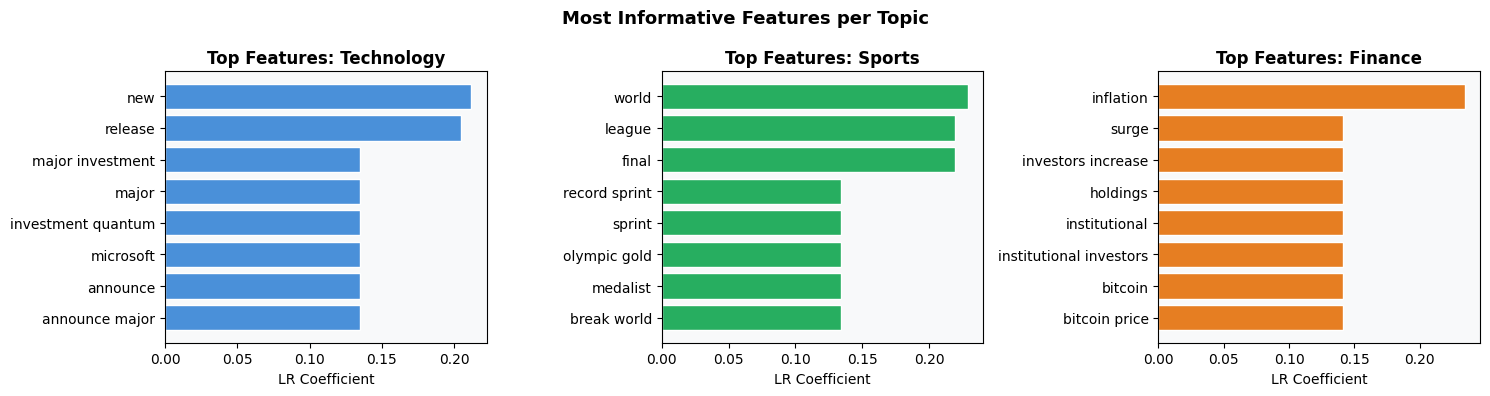


🔮 Predictions from the pipeline:

  [Technology  ]  Apple launches new AI-powered chip for MacBooks
  [Technology  ]  Manchester City sign striker for record transfer fee
  [Technology  ]  Dow Jones falls 500 points on recession fears
  [Technology  ]  Samsung unveils next generation foldable smartphone
  [Sports      ]  LeBron James scores record points in season opener
  [Technology  ]  Hedge funds increase exposure to Treasury bonds


In [26]:

# Capstone Solution — End-to-End NLP Pipeline
import re, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# ── Dataset ───────────────────────────────────────────────────
headlines = [
    "Apple releases new iPhone with advanced AI features",
    "Google DeepMind develops breakthrough in protein folding research",
    "Microsoft announces major investment in quantum computing",
    "OpenAI releases GPT next generation language model update",
    "Tesla develops new battery technology for electric vehicles",
    "Meta launches new virtual reality headset for consumers",
    "Real Madrid wins UEFA Champions League final in dramatic fashion",
    "Serena Williams announces retirement from professional tennis",
    "NBA finals set new record with highest television audience ever",
    "World Cup qualifying results surprise football fans worldwide",
    "Olympic gold medalist breaks world record in sprint event",
    "Premier League title race goes down to final day of season",
    "Federal Reserve raises interest rates to combat inflation",
    "Stock markets reach record highs amid strong earnings reports",
    "Bitcoin price surges as institutional investors increase holdings",
    "IMF warns of global recession risk in annual economic outlook",
    "JPMorgan reports record quarterly profits beating analyst forecasts",
    "Inflation falls to lowest level in three years says government",
]
topic_labels = [0]*6 + [1]*6 + [2]*6
topic_names  = {0: "Technology", 1: "Sports", 2: "Finance"}

# ─────────────────────────────────────────────────────────────
# Step 1-4: Custom text preprocessor
# We use LEMMATISATION over stemming because:
#   • Topic classification requires accurate word forms
#   • "records" → "record" (correct), not "record" → "record" (same luck with stem)
#   • "earnings" → "earning" keeps meaning; stemming gives "earn" which is fine too
#     but lemmatisation also correctly handles irregular forms like "indices"→"index"
# ─────────────────────────────────────────────────────────────

STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess(text: str) -> str:
    """
    Full preprocessing pipeline:
      1. Lowercase
      2. Remove punctuation & numbers
      3. Tokenize
      4. Remove stopwords
      5. Lemmatise (verb form to normalise tenses)
    """
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Tokenize
    tokens = word_tokenize(text)
    # 4. Stopword removal + 5. Lemmatisation
    tokens = [
        lemmatizer.lemmatize(t, pos=wordnet.VERB)
        for t in tokens
        if t.isalpha() and t not in STOP_WORDS
    ]
    return " ".join(tokens)

# Preview preprocessing
print("📋 Preprocessing Preview\n")
for h in headlines[:3]:
    print(f"  RAW : {h}")
    print(f"  PROC: {preprocess(h)}\n")

# ─────────────────────────────────────────────────────────────
# Step 5-6: TF-IDF + Logistic Regression Pipeline
# ─────────────────────────────────────────────────────────────

processed_headlines = [preprocess(h) for h in headlines]

X_train, X_test, y_train, y_test = train_test_split(
    processed_headlines, topic_labels,
    test_size=0.25, random_state=42, stratify=topic_labels
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=500)),
    ("clf",   LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                                  multi_class='multinomial', solver='lbfgs')),
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

cv_scores = cross_val_score(pipeline, processed_headlines, topic_labels,
                             cv=3, scoring="f1_macro")

# ─────────────────────────────────────────────────────────────
# Step 7: Evaluation
# ─────────────────────────────────────────────────────────────
print("\n📊 Classification Report\n")
print(classification_report(
    y_test, preds,
    target_names=[topic_names[i] for i in sorted(topic_names)]
))
print(f"Cross-validation F1 (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(topic_names.values()),
            yticklabels=list(topic_names.values()),
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Capstone — Topic Classifier Confusion Matrix",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# Most informative features per class
tfidf_vocab = np.array(pipeline.named_steps["tfidf"].get_feature_names_out())
coefs       = pipeline.named_steps["clf"].coef_

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, class_id in zip(axes, sorted(topic_names)):
    top_idx = np.argsort(coefs[class_id])[-8:][::-1]
    ax.barh(tfidf_vocab[top_idx][::-1], coefs[class_id][top_idx][::-1],
            color=["#4A90D9","#27AE60","#E67E22"][class_id], edgecolor="white")
    ax.set_title(f"Top Features: {topic_names[class_id]}", fontweight="bold")
    ax.set_xlabel("LR Coefficient")
    ax.set_facecolor("#f8f9fa")
fig.suptitle("Most Informative Features per Topic", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Step 8: predict_topic function
# ─────────────────────────────────────────────────────────────

def predict_topic(text: str) -> str:
    """
    Given a raw text string, preprocess and return the predicted topic.
    
    Parameters
    ----------
    text : str
        Raw headline or document.
    
    Returns
    -------
    str
        One of 'Technology', 'Sports', or 'Finance'.
    """
    cleaned    = preprocess(text)
    prediction = pipeline.predict([cleaned])[0]
    return topic_names[prediction]

# ── Test predictions ──────────────────────────────────────────
print("\n🔮 Predictions from the pipeline:\n")
test_inputs = [
    "Apple launches new AI-powered chip for MacBooks",
    "Manchester City sign striker for record transfer fee",
    "Dow Jones falls 500 points on recession fears",
    "Samsung unveils next generation foldable smartphone",
    "LeBron James scores record points in season opener",
    "Hedge funds increase exposure to Treasury bonds",
]
for t in test_inputs:
    label = predict_topic(t)
    print(f"  [{label:<12}]  {t}")


---
## 📚 Resources & Further Learning

### 🔑 Key Libraries
| Library | Purpose | Link |
|---------|---------|------|
| **NLTK** | Tokenization, stemming, corpora | [nltk.org](https://www.nltk.org) |
| **spaCy** | Industrial-strength NLP | [spacy.io](https://spacy.io) |
| **scikit-learn** | ML models + vectorizers | [scikit-learn.org](https://scikit-learn.org) |
| **Hugging Face** | Transformers + pre-trained models | [huggingface.co](https://huggingface.co) |
| **Gensim** | Word2Vec, Doc2Vec, topic models | [radimrehurek.com/gensim](https://radimrehurek.com/gensim) |

---

### 📖 Courses & Books

#### Free
- 📺 [Stanford CS224N — NLP with Deep Learning (YouTube)](https://www.youtube.com/playlist?list=PLoROMvodv4rMFqRtEuo6SGjY4XbRIVx8Z)
- 📺 [fast.ai NLP Course](https://www.fast.ai)
- 📝 [Hugging Face NLP Course (free, interactive)](https://huggingface.co/learn/nlp-course)
- 📝 [Kaggle NLP in Python (micro-course)](https://www.kaggle.com/learn/natural-language-processing)

#### Books
- 📗 *Speech and Language Processing* — Jurafsky & Martin *(free PDF online)*
- 📘 *Natural Language Processing with Python* — Bird, Klein & Loper *(the NLTK book, free online)*
- 📙 *Natural Language Processing with Transformers* — Tunstall, von Werra & Wolf

---

### 🔬 Key Papers
| Paper | What it introduced |
|-------|--------------------|
| [Bag of Words (Salton, 1975)](https://dl.acm.org/doi/10.1145/361219.361220) | BoW model for IR |
| [TF-IDF (Sparck Jones, 1972)](https://www.emerald.com/insight/content/doi/10.1108/eb026526) | Term weighting |
| [Word2Vec (Mikolov et al., 2013)](https://arxiv.org/abs/1301.3781) | Dense word embeddings |
| [GloVe (Pennington et al., 2014)](https://nlp.stanford.edu/pubs/glove.pdf) | Global vectors |
| [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762) | The Transformer |
| [BERT (Devlin et al., 2018)](https://arxiv.org/abs/1810.04805) | Bidirectional transformers |

---

### 🗺️ What Comes Next — The Road to Transformers

```
BoW / TF-IDF          → Dense Embeddings (Word2Vec, GloVe)
                       → Sequence Models (RNN, LSTM)
                       → Attention Mechanism
                       → Transformer Architecture
                       → BERT, GPT, T5, LLaMA ...
```

The limitation we saw in Section 8 — models treating words as isolated entities —  
was solved by **attention mechanisms** that let every word attend to every other word.

---

### 🧪 Practice Datasets

| Dataset | Task | Source |
|---------|------|--------|
| IMDB Reviews | Sentiment (binary) | `datasets` library |
| 20 Newsgroups | Multi-class classification | `sklearn.datasets` |
| AG News | Topic classification | Hugging Face Hub |
| SMS Spam Collection | Spam detection | [UCI ML Repository](https://archive.ics.uci.edu/dataset/228) |
| SQuAD | Question answering | [rajpurkar.github.io](https://rajpurkar.github.io/SQuAD-explorer/) |

---

*Notebook prepared for NLP Fundamentals Workshop — Track 1 · Beginner*  
*Hosted by Nawel · Duration: 1 Hour*
